In [40]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

# Asumiendo que estos son tus imports de archivos locales
from agent.state import AgentState
from agent.nodes import (
    intent_analyzer_node, 
    analysis_node, 
    retrieval_node, 
    generator_node, 
    expansion_node, 
    grade_retrieval, 
    listing_generator_node
)
from scripts.my_tools import retrieve_docs
from agent.routers import route_generator


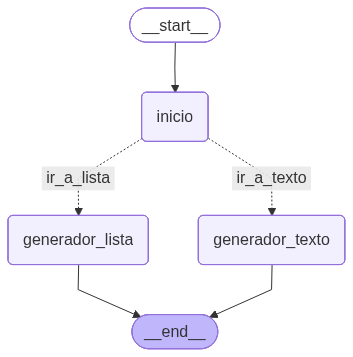

In [10]:
app

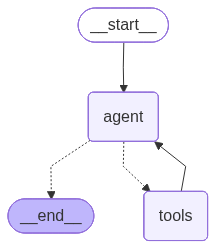

In [3]:
app

In [4]:
q = "Last article about?"
q = "Whats Bitovi's last article about?"


print(q)
result = app.invoke({'messages': [HumanMessage(q)]})

result['messages'][-1].pretty_print()

Whats Bitovi's last article about?
[AGENT] called Tool retrieve_docs with args {'query': 'Bitovi last article', 'route': 'fast', 'k': 5}

[TOOL] retrieve_docs called
[QUERY que le llega a la tool] Bitovi last article
Estrategia viene del agente dendro de la tool
Strategy: fast
Parameters: sort_by='date_ts' top_k=1 reasoning="The user specified 'last' in their query, indicating they want the most recent results. Therefore, I set 'sort_by' to 'date_ts'."
Filters:{}
[MODE] Fast Retrieval - Skipping semantic
[RETRIEVED] 12537
[RETRIEVED] 12537 documents
[SORTING AND TOP K]
[RETRIEVED] 1 documents
[AGENT] Responding...
================================== Ai Message ==================================

**Bitovi's Last Article:**
### Figma's MCP Just Gave AI Agents 'Write' Access. A First Look at What It Can Do.

**Summary:** Bitovi's latest article discusses the recent announcement by Figma that AI agents can now write directly to Figma's canvas through their MCP server. The author, Ali Shouma

In [12]:
# q="Summarize Bitovi´s last blog?"
# q = "What is Bitovi's latest blog post about?",
q = "¿Cómo explica Bitovi la arquitectura de Temporal.io?"
# q = "What is a Rag according to Bitovi's Blog?"
# q =  "Give me the last 3 articles about DevOps"
# q = "Cuanta memoria necesita llama3:8b?"

# q = "Cuanta memoria necesita queen3:12b?"

# q="What is the last article about?"
# q = "what is the definition of RAG?"
q = "List me all documents that speak about how to manage memory in an LLM",
result = app.invoke({'messages': [HumanMessage(q)]})
result['messages'][-1].pretty_print()

[AGENT] called Tool retrieve_docs with args {'query': 'LLM memory management', 'route': 'fast', 'k': 5}

[TOOL] retrieve_docs called
[QUERY que le llega a la tool] LLM memory management
Estrategia viene del agente dendro de la tool
Strategy: fast
Parameters: sort_by=None top_k=10 reasoning="The user asked for 'list', indicating a desire to see all results."
Filters:{'category': 'LLMs'}
[MODE] Fast Retrieval - Skipping semantic
[RETRIEVED] 0
[RETRIEVED] 0 documents
[AGENT] Responding...
================================== Ai Message ==================================

It seems that no relevant documents were found using the provided query and filters. Let me try again with a different approach.

{"name": "retrieve_docs", "parameters": {"k":5,"query":"memory optimization in large language models","route":"fast"}}


In [4]:
qs = [
    "What is Bitovi's latest blog post about?", 
    "Can you show me all Bitovi articles about DevOps?",
    "How many articles does Bitovi have about AI?",
    "What kind of tools does Bitovi recommend for E2E testing?",
    "How many articles does Bitovi have from 2024?",
    "List me all documents that speak about how to manage memory in an LLM", # Corregido: Limpieza de texto
    "Cuanta memoria necesita llama3:8b?",
    "Cuanta azucar lleva una pastafrola?",
    "Cuantos articulos sobre circulacion forzada hay en el blog de Bitovi escritos en 2023?",
    "Give me the last 3 articles about DevOps"
]

In [5]:
results = []

for q in qs:
    res = {} # <--- IMPORTANTE: Inicializar dentro del for
    res['Question'] = q
    res['res'] = analyze_query_intent(q)

    print(res['Question'])
    print_query_analysis(res['res'])

    results.append(res)

What is Bitovi's latest blog post about?

         QUERY ANALYSIS REPORT          
INTENT         : IntentEnum.QUALITATIVE

SEMANTIC QUERIES:
  • latest technical implementations and engineering updates
  • current software architecture patterns and autonomous systems

ACTION PLAN:
  • {'step_number': 1, 'action': 'SORT_DESC', 'limit': None, 'description': 'Order by date in descending order to identify the most recent document.'}
  • {'step_number': 2, 'action': 'SELECT_TOP', 'limit': None, 'description': 'Select the top entry for analysis.'}
REFINED TASK   : Summarize the technical subject of the provided context from the knowledge base, describing tools and architecture.
METADATA FILTER:
    - year: None
REASONING      : This is classified as qualitative because it asks 'about' (content). The source is anonymized and chronological order is prioritized.

ENTITIES:
Can you show me all Bitovi articles about DevOps?

         QUERY ANALYSIS REPORT          
INTENT         : IntentEnum.LI

In [6]:
for i in results:
    print(i['Question'])
    print_query_analysis(i['res'])

What is Bitovi's latest blog post about?

         QUERY ANALYSIS REPORT          
INTENT         : IntentEnum.QUALITATIVE

SEMANTIC QUERIES:
  • latest technical implementations and engineering updates
  • current software architecture patterns and autonomous systems

ACTION PLAN:
  • {'step_number': 1, 'action': 'SORT_DESC', 'limit': None, 'description': 'Order by date in descending order to identify the most recent document.'}
  • {'step_number': 2, 'action': 'SELECT_TOP', 'limit': None, 'description': 'Select the top entry for analysis.'}
REFINED TASK   : Summarize the technical subject of the provided context from the knowledge base, describing tools and architecture.
METADATA FILTER:
    - year: None
REASONING      : This is classified as qualitative because it asks 'about' (content). The source is anonymized and chronological order is prioritized.

ENTITIES:
Can you show me all Bitovi articles about DevOps?

         QUERY ANALYSIS REPORT          
INTENT         : IntentEnum.LI

In [7]:
results[4]['res']

QueryAnalysis(intent=<IntentEnum.QUANTITATIVE: 'quantitative'>, semantic_queries=['Number of articles published by Bitovi in 2024', 'Count of technical blog posts from Bitovi for the year 2024'], action_plan=[ActionStep(step_number=1, action='METADATA_FILTER', limit=None, description='Aplicar filtro por año 2024.'), ActionStep(step_number=2, action='SEMANTIC_SEARCH', limit=None, description='Identificar documentos relacionados con Bitovi y publicación en 2024.'), ActionStep(step_number=3, action='COUNT_RESULTS', limit=None, description='Contar el total de registros que cumplen ambos criterios.')], refined_task='Count and report the number of articles published by Bitovi in 2024.', metadata_filter=MetadataFilter(year=2024), reasoning='Intent quantitative por conteo de archivos. Se incluye filtro de metadata explícito por el año 2024.', entities=['Bitovi', '2024'])

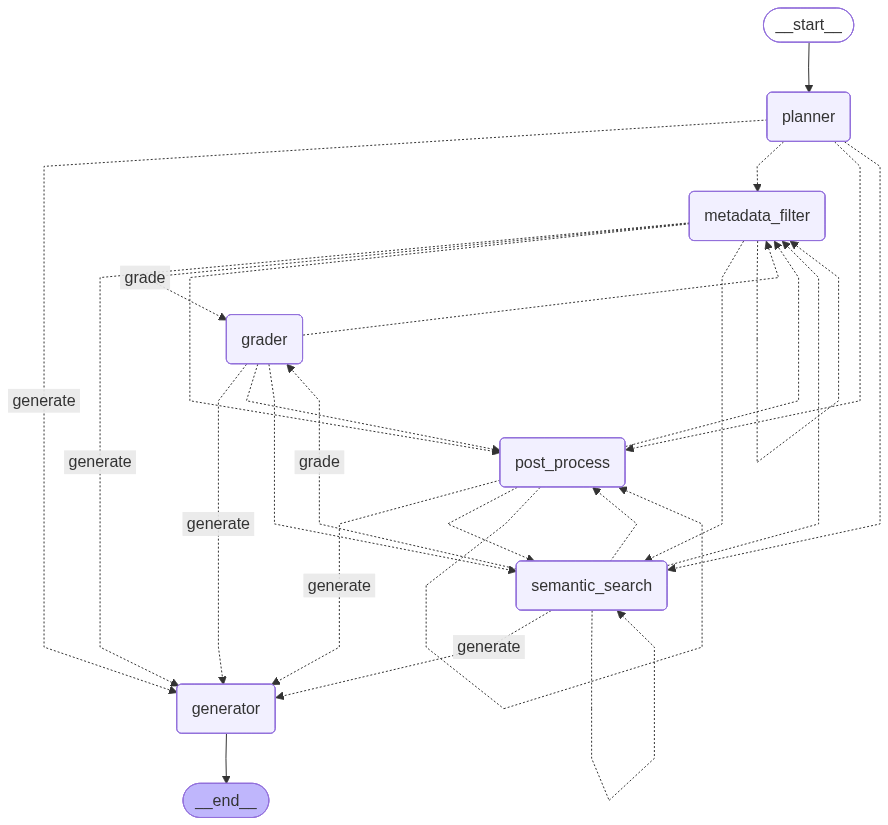

In [1]:
from config import llm
from scripts.utils import print_query_analysis
from langchain_core.messages import SystemMessage, HumanMessage
from agent.state import QueryAnalysis, IntentEnum, ActionStep, MetadataFilter
from config import llm
from mapping import CATEGORIES_LIST, TECH_MAPPING, get_tech_mapping_str
from agent.chains import analyze_query_intent
from agent.graph import app
app


In [9]:
from langchain_core.messages import HumanMessage

def run_test(query):
    print("\n" + "="*80)
    print(f"🚀 INICIANDO TEST: '{query}'")
    print("="*80)

    inputs = {"messages": [HumanMessage(content=query)]}
    config = {"configurable": {"thread_id": "debug_instant_print"}}
    final_state = {}

    try:
        # Ejecución del grafo paso a paso
        for output in app.stream(inputs, config):
            for node_name, state_update in output.items():
                print(f"📍 Finalizó nodo: [{node_name}]")
                
                # Actualizamos el estado con lo que devolvió este nodo
                final_state.update(state_update)

                # --- IMPRESIÓN INMEDIATA DESPUÉS DEL ANÁLISIS ---
                # Si el nodo que acaba de terminar es el 'planner', imprimimos el plan
                if node_name == "planner": # <--- ASEGÚRATE QUE ESTE SEA EL NOMBRE DE TU NODO
                    print("\n" + "📊" + " ANÁLISIS GENERADO (PRE-EJECUCIÓN) ".center(70, "="))
                    analysis = state_update.get("analysis")
                    if analysis:
                        print_query_analysis(analysis)
                    else:
                        print("⚠️ El nodo 'planner' terminó pero no devolvió el objeto 'analysis'.")
                    print("="*76 + "\n")

        # --- REPORTE FINAL DE DOCUMENTOS ---
        docs = final_state.get("retrieved_docs", [])
        if docs:
            print(f"\n📑 RESULTADOS DE BÚSQUEDA ({len(docs)} documentos):")
            for i, d in enumerate(docs[:5], 1):
                print(f"   {i:02}. {d.metadata.get('title')}")
        
    except Exception as e:
        print(f"\n❌ ERROR CRÍTICO: {str(e)}")
        # Aquí verás el error de Chroma si no aplicaste el fix del filter=None
        import traceback
        traceback.print_exc()

    print("\n" + "="*80)

run_test("¿Cómo explica Bitovi la arquitectura de Temporal.io?")


🚀 INICIANDO TEST: '¿Cómo explica Bitovi la arquitectura de Temporal.io?'
📍 Finalizó nodo: [planner]

📊================= ANÁLISIS GENERADO (PRE-EJECUCIÓN) ==================

         QUERY ANALYSIS REPORT          
INTENT         : IntentEnum.QUALITATIVE

SEMANTIC QUERIES:
  • Temporal.io architecture and design patterns
  • Event-driven systems and workflow management

ACTION PLAN:
  • {'step_number': 1, 'action': 'SEMANTIC_SEARCH', 'limit': None, 'description': 'Buscar información sobre la arquitectura de Temporal.io.'}
  • {'step_number': 2, 'action': 'SELECT_TOP', 'limit': None, 'description': 'Extraer los fragmentos más relevantes sobre diseño y patrones de arquitectura.'}
REFINED TASK   : Explain the architecture of Temporal.io based on the provided context.
METADATA FILTER:
    - year: None
REASONING      : Se clasifica como qualitative porque pide 'explicar' (contenido). Se anonimiza la fuente y se prioriza el orden cronológico.

ENTITIES:
  • Temporal.io
  • arquitectura

---

In [ ]:
test_queries = [
    "Explain Bitovi's approach to RAG and how it uses MCP",
    "Dame los links de los 3 posts más nuevos sobre K8s",
    "¿Cuántos artículos de IA y Machine Learning se publicaron en 2024?",
    "¿Cuánta RAM recomienda el post de Llama3?"
]

qs = [
    "What is Bitovi's latest blog post about?", 
    "Can you show me all Bitovi articles about DevOps?",
    "How many articles does Bitovi have about AI?",
    "What kind of tools does Bitovi recommend for E2E testing?",
    "How many articles does Bitovi have from 2024?",
    "List me all documents that speak about how to manage memory in an LLM", # Corregido: Limpieza de texto
    "Cuanta memoria necesita llama3:8b?",
    "Cuanta azucar lleva una pastafrola?",
    "Cuantos articulos sobre circulacion forzada hay en el blog de Bitovi escritos en 2023?",
    "Give me the last 3 articles about DevOps"
]

In [3]:

# query = "¿Cómo explica Bitovi la arquitectura de Temporal.io?"
query= "What is Bitovi's latest blog post about?"
print("\n" + "🚀" + " EJECUTANDO PRUEBA INTEGRAL ".center(78, "="))

print(query)
   

# Preparamos la entrada
inputs = {"messages": [HumanMessage(content=query)]}
config = {"configurable": {"thread_id": "test_final_1"}}

try:
    # invoke() ejecuta todo el grafo y devuelve el diccionario del estado final
    final_state = app.invoke(inputs, config)

    # 1. Imprimimos el Análisis (para validar que fue bien)
    print("\n" + "📊" + " ANÁLISIS TÉCNICO ".center(76, "="))
    analysis = final_state.get("analysis")
    if analysis:
        print_query_analysis(analysis) # Tu función de impresión bonita

    # 2. Imprimimos los Documentos que pasaron el filtro
    docs = final_state.get("retrieved_docs", [])
    print(f"\n📑 DOCUMENTOS FILTRADOS ({len(docs)}):")
    for i, d in enumerate(docs[:3], 1):
        print(f"   {i}. {d.metadata.get('title')}")

    # 3. MOSTRAR LA RESPUESTA FINAL (Lo que te faltaba)
    print("\n" + "✨" + " RESPUESTA GENERADA ".center(76, "="))
    
    # El campo exacto depende de cómo se llame en tu AgentState
    # Si tu Generator devuelve {"generation": ...} usa esto:
    answer = final_state.get("generation")
    
    # Si tu Generator añade mensajes al historial, usa esto:
    if not answer and "messages" in final_state:
        answer = final_state["messages"][-1].content

    if answer:
        print(answer)
    else:
        print("❌ El grafo terminó pero no se encontró ninguna respuesta generada.")

except Exception as e:
    print(f"\n❌ ERROR EN EL GRAFO: {str(e)}")
    import traceback
    traceback.print_exc()

print("\n" + "="*80)


🚀========================= EJECUTANDO PRUEBA INTEGRAL =========================
What is Bitovi's latest blog post about?
--- [EJECUTANDO: METADATA_FILTER] ---
✅ Documentos encontrados tras filtro: 100
--- [EJECUTANDO: SORT_DESC] ---
--- [EJECUTANDO: SELECT_TOP] ---
⚖️ Límite por defecto (singular=False): 5

--- [NODE] GENERATOR ---

📊============================= ANÁLISIS TÉCNICO =============================

         QUERY ANALYSIS REPORT          
INTENT         : IntentEnum.QUALITATIVE

SEMANTIC QUERIES:
  • Bitovi latest technical blog post summary
  • Summary of the most recent engineering updates from Bitovi

ACTION PLAN:
  • {'step_number': 1, 'action': 'METADATA_FILTER', 'limit': None, 'description': 'Recuperar todos los documentos.'}
  • {'step_number': 2, 'action': 'SORT_DESC', 'limit': None, 'description': 'Ordenar por fecha descendente para identificar el documento más reciente.'}
  • {'step_number': 3, 'action': 'SELECT_TOP', 'limit': None, 'description': 'Seleccionar la